# 2b — $\theta_{13}$ from a *fixed* near reactor: can JUNO's size replace the mobile stops?

Notebook 2 reached $\sigma(\theta_{13})\approx0.11°$ with a **movable** reactor: an anchor
stop at $200$ m and a physics stop at $1.2$ km, the anchor cancelling flux and
normalisation systematics. This notebook asks the cheaper question: **one fixed reactor**,
with the $\theta_{13}$ oscillation's $L/E$ dependence *inside the JUNO volume* doing the
sampling.

The physics is set by two numbers. The $\theta_{13}$ oscillation length is
$\approx1.6\,{\rm km}\times E[{\rm MeV}]/(\Delta m^2_{ee}/2.5\times10^{-3})$, so:

* the **phase across the detector** ($\Delta L = 33$ m) is $\Delta\Phi\approx0.026$ rad at
  4 MeV — the *same* at every standoff — while
* the **mean phase** grows with distance: $\Phi = 0.04$ at $50$ m, $0.16$ at $200$ m,
  $0.47$ at $600$ m, $1.2$ at $1.5$ km.

At $50$ m the entire detector sits at $L/E\approx0$: whatever the statistics ($6\times10^7$
events!), $\sin^2\Phi\sim10^{-3}$ and there is nothing to measure. The lever arm only
opens at kilometre baselines — where $1/D^2$ has already cost a factor $900$ in rate. So the
fixed-reactor sensitivity is a trade between rate and phase, and this notebook maps it.

**Ingredients** (`reactor/fixed_theta13.py`):

* $\Delta m^2_{ee}$ is not free: JUNO's own GW reactors at $52.5$ km determine it through
  the fine atmospheric wiggles, independently of the near source. Its projected precision
  is computed with the standard machinery and used as a Gaussian prior.
* A **Monte Carlo of vertices** — uniform in the fiducial sphere, weighted by the
  $1/L^2$ flux, with the finite core ($0.5$ m) and JUNO's vertex resolution
  ($10\,{\rm cm}/\sqrt{E}$) applied by sampling — gives each reconstructed-$L$ bin its
  *true*-baseline distribution, so geometric acceptance and resolution projection are
  done by sampling, not formula. The analytic $A(L)/L^2$ is used only to *validate* it.
* Fit on the $(L_{\rm reco}, E_{\rm reco})$ binned IBD spectrum, Asimov Fisher with the
  joint-mode covariance: **free flux normalisation** ($10\%$), the measured 25-mode U235
  shape covariance, U238, fuel evolution, energy scale/bias/resolution, and a
  Gaussian-correlated response uniformity field over $L$ (0.5%, 3 m).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from reactor import plotting as pl
from reactor.fixed_theta13 import (FixedReactorTheta13, VertexMonteCarlo,
                                   TwoFixedReactorsTheta13)
from reactor.theta13 import NearFarTheta13, DEFAULT_TRUTH

pl.use_style()
YEAR = 365.25

# 1. the dm2_ee prior from JUNO's far reactors
far = NearFarTheta13(far_days=6 * YEAR, stops=())
ferr = far.fisher_errors()
SIG_DM2 = ferr["dm2_ee"]
print(f"JUNO far reactors, 6 yr: sigma(dm2_ee) = {SIG_DM2:.2e} eV^2 "
      f"({100*SIG_DM2/DEFAULT_TRUTH.dm2_ee:.2f}%), sigma(sin^2 th13) = "
      f"{ferr['sin2_theta13']:.4f} -> the far detector measures dm2_ee well and")
print("theta13 poorly, which is exactly the division of labour the near reactor needs.")

JUNO far reactors, 6 yr: sigma(dm2_ee) = 8.66e-06 eV^2 (0.35%), sigma(sin^2 th13) = 0.0037 -> the far detector measures dm2_ee well and
theta13 poorly, which is exactly the division of labour the near reactor needs.


## The vertex Monte Carlo and its validation

For $D=100$ m the baseline spans $83$–$117$ m. Sampled true baselines must reproduce the
analytic shell distribution $A(L)/L^2$; reconstructed baselines then show the effect of
the $10\,{\rm cm}/\sqrt{E}$ resolution and the $0.5$ m core.

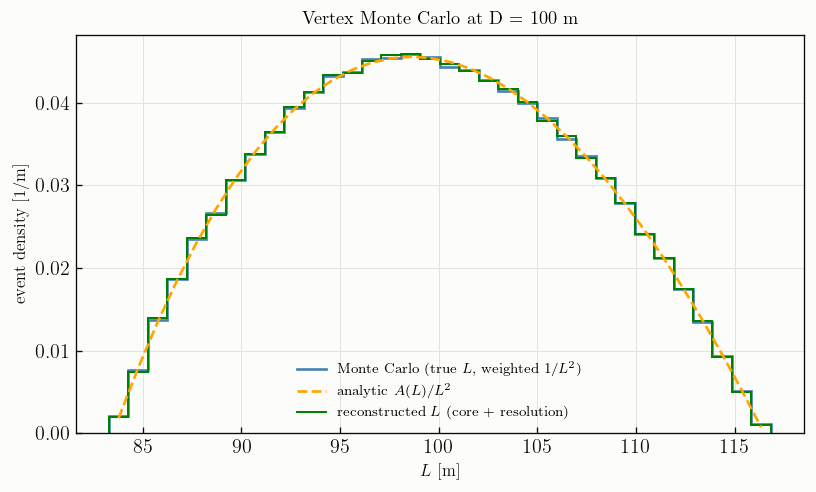

MC / analytic: max |ratio - 1| = 0.022 (consistent with MC statistics)


In [2]:
mc = VertexMonteCarlo(100.0)
ev = mc.sample(300_000, lambda n: np.full(n, 4.0))
h, edges = np.histogram(ev["l_true"], bins=34, weights=ev["weight"], density=True)
cen = 0.5 * (edges[:-1] + edges[1:])
an = VertexMonteCarlo.analytic_dNdL(cen, 100.0, 16.5)
an /= np.trapezoid(an, cen)

fig, ax = plt.subplots(figsize=(6.9, 4.2))
ax.stairs(h, edges, color=pl.BLUE, lw=1.6, label="Monte Carlo (true $L$, weighted $1/L^2$)")
ax.plot(cen, an, color=pl.ORANGE, lw=1.6, ls="--", label=r"analytic $A(L)/L^2$")
hr, _ = np.histogram(ev["l_reco"], bins=edges, weights=ev["weight"], density=True)
ax.stairs(hr, edges, color=pl.GREEN, lw=1.2, label="reconstructed $L$ (core + resolution)")
ax.set_xlabel("$L$ [m]"); ax.set_ylabel("event density [1/m]")
ax.set_title("Vertex Monte Carlo at D = 100 m")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

inner = (cen > 86) & (cen < 114)
print(f"MC / analytic: max |ratio - 1| = {np.max(np.abs(h/an - 1)[inner]):.3f} "
      "(consistent with MC statistics)")

## The scan: four representative standoffs

$50$ m, $200$ m, $600$ m and $1.5$ km, each $10$ MW for 3 years at $90\%$ duty, with the
$\Delta m^2_{ee}$ prior from the far reactors. Alongside: the same data fit *without*
vertex binning (integrated), and the statistics-only floor.

In [3]:
def deg(D, **kw):
    return FixedReactorTheta13(D, years=3.0, sigma_dm2ee_prior=SIG_DM2, **kw).sigma_theta13_deg()

OFF = dict(sigma_norm=1e-9, sigma_uniformity=1e-9, sigma_scale=1e-9, sigma_bias=1e-9,
           sigma_res=1e-9, sigma_u238=1e-9, sigma_evolution=1e-9,
           use_flux_covariance=False)
t0 = time.time()
rows = []
for D in (50.0, 200.0, 600.0, 1500.0):
    m = FixedReactorTheta13(D, years=3.0, sigma_dm2ee_prior=SIG_DM2)
    phi = 1.267 * DEFAULT_TRUTH.dm2_ee * D / 4.0
    rows.append([f"{D:.0f}", m.total_events, phi, m.sigma_theta13_deg(),
                 deg(D, l_binned=False), deg(D, **OFF)])
print(pl.table(rows, ["D [m]", "IBD events", "mean phase @4 MeV", "sigma(th13) [deg]",
                      "no L bins", "stat only"], floatfmt="{:.3g}"))
print(f"({time.time()-t0:.0f} s)")
print()
print("Reading the table: at 50 m the whole detector is at L/E ~ 0 -- 6e7 events buy")
print("nothing (20 deg). The lever opens with distance, but every configuration sits far")
print("above its statistics floor: the systematics that L-binning does NOT cancel are the")
print("limiter. Which ones is the next question.")

D [m]  IBD events  mean phase @4 MeV  sigma(th13) [deg]  no L bins  stat only
-----------------------------------------------------------------------------
50     6e+07       0.0391             19.7               480        3.13     
200    3.67e+06    0.156              16                 30.2       0.817    
600    4.08e+05    0.469              4.06               4.15       0.31     
1500   6.52e+04    1.17               2.5                2.51       0.249    
(2 s)

Reading the table: at 50 m the whole detector is at L/E ~ 0 -- 6e7 events buy
nothing (20 deg). The lever opens with distance, but every configuration sits far
above its statistics floor: the systematics that L-binning does NOT cancel are the
limiter. Which ones is the next question.


In [4]:
D = 1500.0
rows = [("all systematics", {}),
        ("no flux-shape covariance", dict(use_flux_covariance=False)),
        ("no energy pulls", dict(sigma_scale=1e-9, sigma_bias=1e-9, sigma_res=1e-9)),
        ("no fuel evolution", dict(sigma_evolution=1e-9)),
        ("no uniformity field", dict(sigma_uniformity=1e-9)),
        ("normalisation known", dict(sigma_norm=1e-9)),
        ("only norm free (all shapes known)",
         dict(use_flux_covariance=False, sigma_scale=1e-9, sigma_bias=1e-9,
              sigma_res=1e-9, sigma_evolution=1e-9, sigma_u238=1e-9,
              sigma_uniformity=1e-9)),
        ("statistics only", OFF)]
tab = [[lab, deg(D, **kw)] for lab, kw in rows]
print(pl.table(tab, ["variant, D = 1.5 km", "sigma(theta13) [deg]"], floatfmt="{:.3f}"))
print()
print("The verdict is physical and sharp. Across a 33 m detector the phase changes by")
print("only 0.026 rad, so the L/E lever inside the volume is a 2% effect; the theta13")
print("information sits mostly in the E-SHAPE of the disappearance at essentially one")
print("baseline -- and that is exactly what the U235 flux-shape covariance and the")
print("energy-scale pulls can mimic. Uniformity is a null (the fit is not using the L")
print("direction much); the flux shape and the free normalisation together account for")
print("the whole factor 10 above the statistics floor. This is precisely the degeneracy")
print("the mobile programme's anchor stop was designed to break -- a fixed reactor cannot")
print("break it alone.")

variant, D = 1.5 km                sigma(theta13) [deg]
-------------------------------------------------------
all systematics                    2.503               
no flux-shape covariance           1.440               
no energy pulls                    2.275               
no fuel evolution                  2.471               
no uniformity field                2.503               
normalisation known                1.106               
only norm free (all shapes known)  0.928               
statistics only                    0.249               

The verdict is physical and sharp. Across a 33 m detector the phase changes by
only 0.026 rad, so the L/E lever inside the volume is a 2% effect; the theta13
information sits mostly in the E-SHAPE of the disappearance at essentially one
baseline -- and that is exactly what the U235 flux-shape covariance and the
energy-scale pulls can mimic. Uniformity is a null (the fit is not using the L
direction much); the flux shape and the free no

## The rescue: a second fixed unit as flux monitor

The mobile scheme's anchor stop can be replaced by a **second fixed reactor of the same
design at $50$ m** — a flux monitor with $\sim6\times10^7$ events that measures the shared
shape systematics (U235 covariance, U238, fuel evolution, energy response) in situ, while
the far unit at $0.6$–$2$ km carries the $L/E$ information. What the pair does *not*
share is the absolute power ratio between the two units, which enters as its own prior.

In [5]:
t0 = time.time()
rows = []
for D in (600.0, 1000.0, 1500.0, 2000.0):
    single = deg(D)
    pair = TwoFixedReactorsTheta13(50.0, D, sigma_dm2ee_prior=SIG_DM2).sigma_theta13_deg()
    rows.append([f"{D:.0f}", single, pair, single / pair])
print(pl.table(rows, ["far unit D [m]", "single fixed", "+ 50 m monitor", "gain"],
               floatfmt="{:.3f}"))
print(f"({time.time()-t0:.0f} s)")

rows = []
for pr in (0.05, 0.02, 0.005, 1e-9):
    m = TwoFixedReactorsTheta13(50.0, 1000.0, sigma_dm2ee_prior=SIG_DM2,
                                sigma_power_ratio=pr)
    rows.append([f"{100*pr:.1f}%" if pr > 1e-8 else "known", m.sigma_theta13_deg()])
print()
print(pl.table(rows, ["power-ratio prior (far unit at 1 km)", "sigma(theta13) [deg]"],
               floatfmt="{:.3f}"))
print()
print("A 50 m monitor recovers a factor 4-7: 0.54 deg at 1 km with a 2% power ratio, and")
print("the ratio prior is the remaining lever -- at 0.5% the pair reaches ~0.3 deg,")
print("close to its statistics floor. Two fixed identical units are a workable, if")
print("less powerful, substitute for the movable source: the near unit plays the anchor")
print("stop and the relative-power knowledge plays the role of the moving reactor's")
print("self-consistency.")

far unit D [m]  single fixed  + 50 m monitor  gain 
---------------------------------------------------
600             4.062         0.605           6.713
1000            2.395         0.544           4.405
1500            2.503         0.762           3.283
2000            1.989         0.819           2.428
(2 s)



power-ratio prior (far unit at 1 km)  sigma(theta13) [deg]
----------------------------------------------------------
5.0%                                  0.562               
2.0%                                  0.544               
0.5%                                  0.398               
known                                 0.240               

A 50 m monitor recovers a factor 4-7: 0.54 deg at 1 km with a 2% power ratio, and
the ratio prior is the remaining lever -- at 0.5% the pair reaches ~0.3 deg,
close to its statistics floor. Two fixed identical units are a workable, if
less powerful, substitute for the movable source: the near unit plays the anchor
stop and the relative-power knowledge plays the role of the moving reactor's
self-consistency.


(11 s)


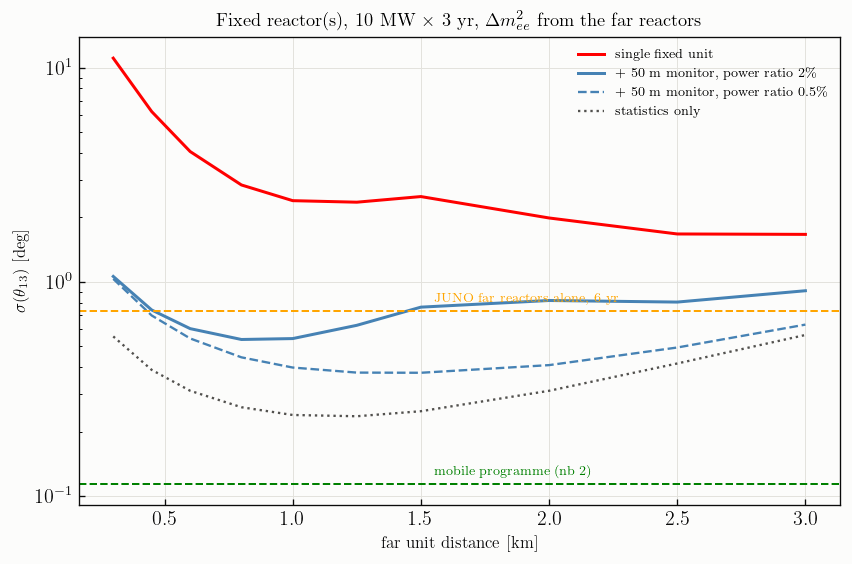

In [6]:
# sigma(theta13) vs far-unit distance, single and paired, with the mobile & far-only refs.
t0 = time.time()
Ds = np.array([300, 450, 600, 800, 1000, 1250, 1500, 2000, 2500, 3000], dtype=float)
single = [deg(D) for D in Ds]
pair = [TwoFixedReactorsTheta13(50.0, D, sigma_dm2ee_prior=SIG_DM2).sigma_theta13_deg()
        for D in Ds]
pair05 = [TwoFixedReactorsTheta13(50.0, D, sigma_dm2ee_prior=SIG_DM2,
                                  sigma_power_ratio=0.005).sigma_theta13_deg() for D in Ds]
stat = [deg(D, **OFF) for D in Ds]
print(f"({time.time()-t0:.0f} s)")

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.semilogy(Ds / 1000, single, color=pl.RED, lw=1.8, label="single fixed unit")
ax.semilogy(Ds / 1000, pair, color=pl.BLUE, lw=1.8,
            label=r"+ 50 m monitor, power ratio 2\%")
ax.semilogy(Ds / 1000, pair05, color=pl.BLUE, ls="--", lw=1.4,
            label=r"+ 50 m monitor, power ratio 0.5\%")
ax.semilogy(Ds / 1000, stat, ":", color=pl.INK_SECONDARY, lw=1.4, label="statistics only")
ax.axhline(0.735, color=pl.ORANGE, lw=1.2, ls="--")
ax.annotate("JUNO far reactors alone, 6 yr", xy=(1.55, 0.80), fontsize=8, color=pl.ORANGE)
ax.axhline(0.114, color=pl.GREEN, lw=1.2, ls="--")
ax.annotate("mobile programme (nb 2)", xy=(1.55, 0.124), fontsize=8, color=pl.GREEN)
ax.set_xlabel("far unit distance [km]"); ax.set_ylabel(r"$\sigma(\theta_{13})$ [deg]")
ax.set_title(r"Fixed reactor(s), 10 MW $\times$ 3 yr, $\Delta m^2_{ee}$ from the far reactors")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

## Summary

| configuration | $\sigma(\theta_{13})$ |
|---|---|
| JUNO far reactors alone, 6 yr | $0.74°$ |
| **one fixed 10 MW unit**, best distance ($\sim1$–$2$ km), 3 yr | $\approx2°$ |
| — its statistics floor | $0.25°$ |
| **two fixed units** (50 m monitor + 1 km), power ratio 2% / 0.5% | $0.54°$ / $\approx0.3°$ |
| mobile programme (notebook 2), 2 yr | $0.11°$ |

* **A single fixed reactor cannot do the job**, and the reason is geometric: across
  JUNO's $33$ m the $\theta_{13}$ phase changes by $0.026$ rad regardless of standoff. The
  volume does *not* provide an $L/E$ lever comparable to moving the source; the
  information is in the $E$-shape at one baseline, degenerate with the measured U235
  shape covariance and the free normalisation (factor $10$ above statistics; uniformity is
  a null). At $50$ m the detector sits at $L/E\approx0$ and no statistics help.
* **The finite size *is* the right tool for the sterile search** (notebook 6, where the
  oscillation length is metres) — it is the wrong tool for $\theta_{13}$, where it is
  kilometres. Same detector, opposite verdicts, for the same reason.
* **A second fixed identical unit at 50 m as flux monitor** breaks the degeneracy the way
  the mobile anchor does, reaching $0.5°$ (2% power ratio) to $0.3°$ (0.5%) — a real
  improvement over the far reactors, at the cost of two reactors instead of one movable
  one, and still a factor $\sim3$–$5$ short of the mobile programme.
* $\Delta m^2_{ee}$ from JUNO's own reactors ($0.35\%$ at 6 yr) is more than sufficient as
  a prior throughout; freeing it changes nothing at these precisions.